In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import LabelEncoder

In [3]:
# Membuat model prediksi pakan
df = pd.read_csv('data_ternak.csv')

In [18]:
le_hewan = LabelEncoder()
df['jenis_hewan'] = le_hewan.fit_transform(df['jenis_hewan'])
le_status = LabelEncoder()
df['status_fisiologis'] = le_status.fit_transform(df['status_fisiologis'])
print(df.head(10))

   jenis_hewan  umur_bulan  berat_aktual  status_fisiologis  target_hijauan  \
0            1          13     19.516116                  1        0.351290   
1            1          12     26.342727                  3        0.474169   
2            1          32     49.614001                  3        0.893052   
3            1          27     41.437213                  2        0.745870   
4            1           5     12.198416                  3        0.219571   
5            1          18     28.366935                  3        0.510605   
6            1          13     24.329686                  1        0.437934   
7            0           3     16.731019                  0        0.301158   
8            0          27     48.429896                  3        0.871738   
9            1          30     52.217825                  3        0.939921   

   target_konsentrat  
0           0.234193  
1           0.316113  
2           0.595368  
3           0.497247  
4           0.1

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [6]:
# 1. Tentukan fitur (input) dan target (output)
# Fitur yang dipakai untuk menebak pakan:
X = df[['jenis_hewan', 'umur_bulan', 'berat_aktual', 'status_fisiologis']] 

In [7]:
# Target yang ingin ditebak:
y_pakan = df[['target_hijauan', 'target_konsentrat']]

In [8]:
# 2. Bagi data menjadi data latih (80%) dan data uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_pakan, test_size=0.2, random_state=42)

In [9]:
# 3. Buat model Machine Learning
model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# 4. Tes seberapa akurat modelnya
prediksi = model.predict(X_test)
error = mean_absolute_error(y_test, prediksi)
print(f"Rata-rata error tebakan model adalah: {error:.4f} kg")

Rata-rata error tebakan model adalah: 0.0007 kg


In [11]:
# Nyobain data baru menggunakan inputan sendiri
hewan = pd.DataFrame({
    'jenis_hewan' : [0],    # 0: Kambing, 1: Domba
    'umur_bulan'          : [12],   # 12 bulan
    'berat_aktual'        : [40],   # 40 kg
    'status_fisiologis'      : [3]    # Status Fisiologis Ter-encode
})

In [12]:
# melakukan prediksi menggunakan model pakan
hasil_prediksi = model.predict(hewan)

In [13]:
# menampilkan output ganda dengan aman
print("==== HASIL REKOMENDASI PAKAN AI ====")
print(f"Kebutuhan target hijauan  : {hasil_prediksi[0][0]:.2f} kg / hari")
print(f"Kebutuhan konsentrat      : {hasil_prediksi [0][1]:.2f} kg / hari")

==== HASIL REKOMENDASI PAKAN AI ====
Kebutuhan target hijauan  : 0.72 kg / hari
Kebutuhan konsentrat      : 0.48 kg / hari


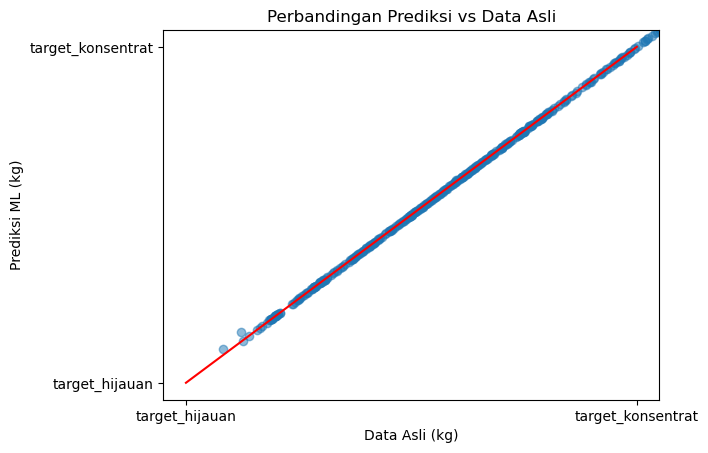

In [14]:
plt.scatter(y_test, prediksi, alpha=0.5)
plt.xlabel("Data Asli (kg)")
plt.ylabel("Prediksi ML (kg)")
plt.title("Perbandingan Prediksi vs Data Asli")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red') # Garis acuan
plt.show()

In [15]:
import joblib 

In [17]:
joblib.dump(model, 'model_prediksi_pakan.joblib')
joblib.dump(le_hewan, 'le_hewan.joblib')
joblib.dump(le_status, 'le_status.joblib')

['le_status.joblib']